Voltaje a 1 min: 12.574943899471165 V
Voltaje a 5 h: 12.127192496576207 V
Voltaje a 10 h: 11.733424316388932 V
Voltaje a 19 h: 10.900067264806632 V


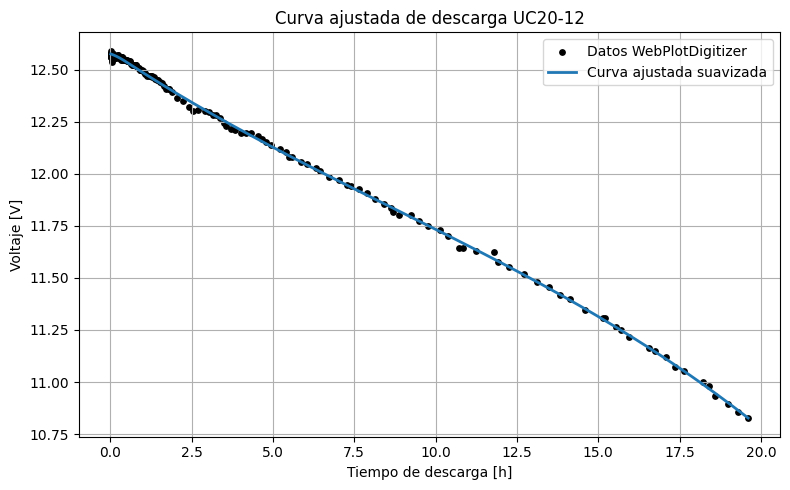

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

archivo = "Default Dataset 1.csv"

df = pd.read_csv(
    archivo,
    sep=";",
    decimal=",",
    header=None,
    names=["t_min", "V"]
)

df = df.sort_values("t_min").reset_index(drop=True)


df["t_h"] = df["t_min"] / 60

t = df["t_h"].values
V = df["V"].values

s = 0.02

curva = UnivariateSpline(t, V, s=s)


t_curva = np.linspace(t.min(), t.max(), 1000)
V_curva = curva(t_curva)

df_curva = pd.DataFrame({
    "t_h": t_curva,
    "V_ajustado": V_curva
})

df_curva.to_csv("curva_descarga_ajustada.csv", index=False)


def voltaje(tiempo, unidad="h"):
    if unidad == "min":
        tiempo = tiempo / 60

    return float(curva(tiempo))

print("Voltaje a 1 min:", voltaje(1, unidad="min"), "V")
print("Voltaje a 5 h:", voltaje(5), "V")
print("Voltaje a 10 h:", voltaje(10), "V")
print("Voltaje a 19 h:", voltaje(19), "V")


plt.figure(figsize=(8,5))

plt.scatter(t, V, s=15, color="black", label="Datos WebPlotDigitizer")
plt.plot(t_curva, V_curva, linewidth=2, label="Curva ajustada suavizada")

plt.xlabel("Tiempo de descarga [h]")
plt.ylabel("Voltaje [V]")
plt.title("Curva ajustada de descarga UC20-12")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import math

E_full = 13.5 
t_exp = 1 / 60
I = 1.07
Q_exp =  I * t_exp
Q = 21.4
R = 0.015

E_exp = voltaje(1, unidad="min")

A = E_full - E_exp
B = 3 / Q_exp

t_nom = 10
Q_nom = I * t_nom
E_nom = voltaje(t_nom, unidad="h")

K = ((E_full - E_nom + A * (math.exp(-B * Q_nom) - 1))* (Q - Q_nom) / Q_nom)
E0 = E_full + K + R * I - A

print("===== PUNTOS UTILIZADOS =====")
print(f"E_full = {E_full:.4f} V")
print(f"t_exp  = {t_exp:.6f} h  ({t_exp*60:.2f} min)")
print(f"Q_exp  = {Q_exp:.6f} Ah")
print(f"E_exp  = {E_exp:.4f} V")

print(f"\nt_nom  = {t_nom:.4f} h")
print(f"Q_nom  = {Q_nom:.4f} Ah")
print(f"E_nom  = {E_nom:.4f} V")

print("\n===== PARÁMETROS TREMBLAY =====")
print(f"E0 = {E0:.4f} V")
print(f"K  = {K:.6f} V")
print(f"A  = {A:.4f} V")
print(f"B  = {B:.4f} Ah^-1")
print(f"R  = {R:.4f} ohm")


===== PUNTOS UTILIZADOS =====
E_full = 13.5000 V
t_exp  = 0.016667 h  (1.00 min)
Q_exp  = 0.017833 Ah
E_exp  = 12.5749 V

t_nom  = 10.0000 h
Q_nom  = 10.7000 Ah
E_nom  = 11.7334 V

===== PARÁMETROS TREMBLAY =====
E0 = 13.4325 V
K  = 0.841520 V
A  = 0.9251 V
B  = 168.2243 Ah^-1
R  = 0.0150 ohm


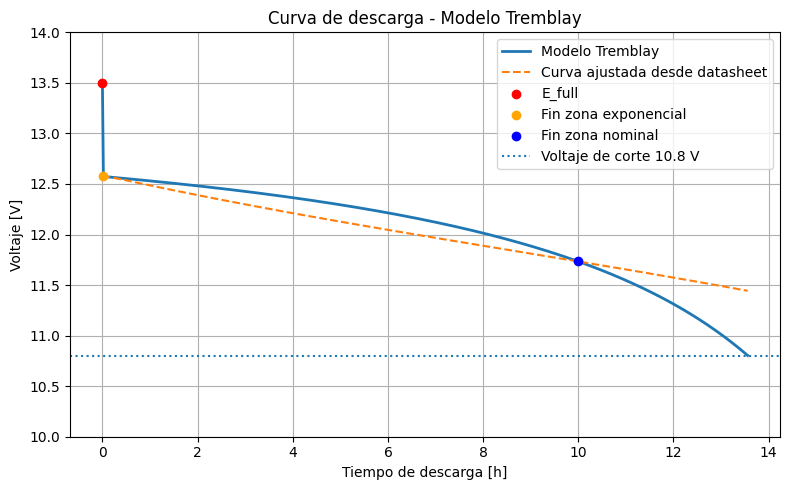

In [ ]:
t_max = Q / I

t_modelo = np.linspace(0, 0.999 * t_max, 1000)

it = I * t_modelo

V_tremblay = E0 - K * Q / (Q - it) + A * np.exp(-B * it) - R * I

V_cut = 10.8

mask = V_tremblay >= V_cut

t_modelo_corte = t_modelo[mask]
V_tremblay_corte = V_tremblay[mask]

V_ajustada = np.array([voltaje(tiempo, unidad="h") for tiempo in t_modelo_corte])

plt.figure(figsize=(8,5))

plt.plot(t_modelo_corte, V_tremblay_corte, label="Modelo Tremblay", linewidth=2)
plt.plot(t_modelo_corte, V_ajustada, label="Curva ajustada desde datasheet", linestyle="--")

plt.scatter(0, E_full, color="red", zorder=5, label="E_full")
plt.scatter(t_exp, E_exp, color="orange", zorder=5, label="Fin zona exponencial")
plt.scatter(t_nom, E_nom, color="blue", zorder=5, label="Fin zona nominal")

plt.axhline(V_cut, linestyle=":", label="Voltaje de corte 10.8 V")

plt.xlabel("Tiempo de descarga [h]")
plt.ylabel("Voltaje [V]")
plt.title("Curva de descarga - Modelo Tremblay")
plt.grid(True)
plt.legend()

plt.ylim(10, 14)

plt.tight_layout()
plt.show()

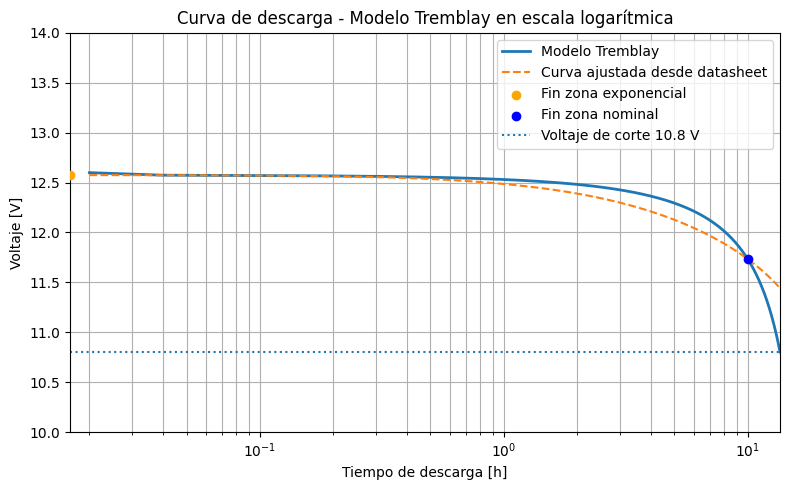

In [ ]:
mask_log = t_modelo_corte > 0

t_log = t_modelo_corte[mask_log]
V_tremblay_log = V_tremblay_corte[mask_log]

V_ajustada_log = np.array([voltaje(tiempo, unidad="h") for tiempo in t_log])

plt.figure(figsize=(8,5))

plt.plot(t_log, V_tremblay_log, label="Modelo Tremblay", linewidth=2)
plt.plot(t_log, V_ajustada_log, label="Curva ajustada desde datasheet", linestyle="--")

plt.scatter(t_exp, E_exp, color="orange", zorder=5, label="Fin zona exponencial")
plt.scatter(t_nom, E_nom, color="blue", zorder=5, label="Fin zona nominal")

plt.axhline(V_cut, linestyle=":", label="Voltaje de corte 10.8 V")

plt.xscale("log")

plt.xlabel("Tiempo de descarga [h]")
plt.ylabel("Voltaje [V]")
plt.title("Curva de descarga - Modelo Tremblay en escala logarítmica")

plt.grid(True, which="both")
plt.legend()

# Límites
plt.ylim(10, 14)
plt.xlim(t_exp, t_log.max())

plt.tight_layout()
plt.show()